In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("../data/trial_1.csv", sep="\t", skiprows=1)


#df2 = pd.read_csv("../data/trial_1.csv", sep="\t")
#df2 = df.drop(df.columns[0,1], axis=1)
'''
Need to check for anti mysin in event name for a different baseline
'''
"""
with open("../data/trial_1.csv") as f:
    for i, line in enumerate(f):
        print(i, line)
        """
df = pd.read_csv(
    "../data/trial_1.csv",
    sep="\t",
    skiprows=1
)

df = df.iloc[:, 9: -1]


print(df.columns)

df.columns = df.columns.str.strip()
df = df.iloc[:-1]
display(df)
"""
if 'ANTIA' in df.columns:
    print("ANTIA column exists")
    baseline = df.iloc[7, -1]
    print(baseline)
print(df.loc[7])
"""
# Find a column related to anti-mysin (case-insensitive, tolerant of variations)
anti_candidates = df.columns[df.columns.str.upper().str.contains("ANTI|MYSIN")]
if len(anti_candidates) > 0:
    anti_col = anti_candidates[0]
    print(f"Using anti-mysin column: {anti_col}")
else:
    anti_col = None
    print("No anti-mysin column found; will fall back to last column as baseline.")

# Choose baseline column (anti_col if found, otherwise last column)
baseline_col = anti_col if anti_col is not None else df.columns[-1]
row_idx_position = 7  
if row_idx_position >= len(df):
    raise IndexError(f"Requested row position {row_idx_position} is out of range for dataframe with {len(df)} rows.")

# get baseline value (coerce to numeric)
baseline_value = pd.to_numeric(df.iloc[row_idx_position][baseline_col], errors="coerce")
if pd.isna(baseline_value):
    raise ValueError(f"Baseline value at row {row_idx_position}, col '{baseline_col}' is not numeric or is missing.")

print("Baseline value:", baseline_value)

row_numeric = df.iloc[row_idx_position].apply(pd.to_numeric, errors="coerce")
new_row = row_numeric - baseline_value

# name the new row and append it
new_row.name = "baseline_subtracted"
# assign directly (works even if existing index is integers)
df.loc[new_row.name] = new_row


# show result
display(df.tail(10))


Index(['BASE', 'PYR+MAL', 'ADP1', 'ADP2', 'ADP3', 'ADPMAX', 'CYTOC', 'SUCC',
       'ROT', 'ANTIA'],
      dtype='object')


,BASE,PYR+MAL,ADP1,ADP2,ADP3,ADPMAX,CYTOC,SUCC,ROT,ANTIA
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,02:12:54,02:19:16,02:25:36,02:31:13,02:36:32,02:45:20,02:50:44,02:55:53,02:59:53,03:04:59
4,02:15:24,02:21:16,02:27:45,02:33:16,02:38:33,02:47:33,02:52:49,02:57:36,03:01:07,03:06:58
5,76,61,65,62,61,67,63,52,37,60
6,176.70556018860583,174.87387082705067,171.3579317908211,166.9360979913335,160.62920709086765,139.53266833553388,125.02387951610439,110.33373083643204,99.32686071490912,97.27989131974897
7,5.44553487340807,8.124295180881536,11.119028585434398,15.083191635061555,25.34250610802208,50.31916649383611,47.40703793923667,61.31369383007669,43.72312467715597,-0.4606482580104265


Using anti-mysin column: ANTIA
Baseline value: -0.4606482580104265


,BASE,PYR+MAL,ADP1,ADP2,ADP3,ADPMAX,CYTOC,SUCC,ROT,ANTIA
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,02:12:54,02:19:16,02:25:36,02:31:13,02:36:32,02:45:20,02:50:44,02:55:53,02:59:53,03:04:59
4,02:15:24,02:21:16,02:27:45,02:33:16,02:38:33,02:47:33,02:52:49,02:57:36,03:01:07,03:06:58
5,76,61,65,62,61,67,63,52,37,60
6,176.70556018860583,174.87387082705067,171.3579317908211,166.9360979913335,160.62920709086765,139.53266833553388,125.02387951610439,110.33373083643204,99.32686071490912,97.27989131974897
7,5.44553487340807,8.124295180881536,11.119028585434398,15.083191635061555,25.34250610802208,50.31916649383611,47.40703793923667,61.31369383007669,43.72312467715597,-0.4606482580104265
baseline_subtracted,5.906183,8.584943,11.579677,15.54384,25.803154,50.779815,47.867686,61.774342,44.183773,0.0


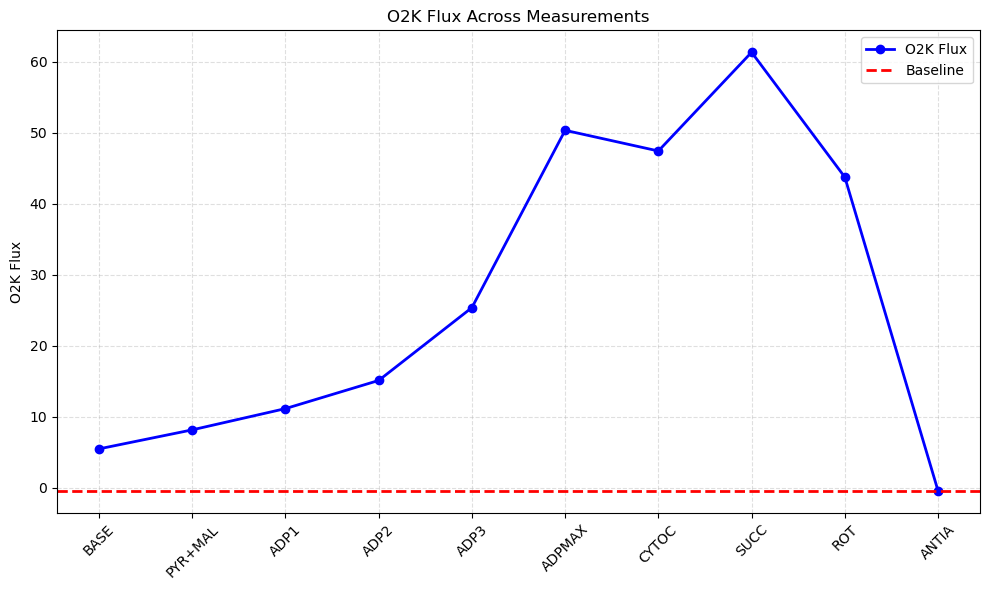

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Use column labels as x positions
x_labels = row_numeric.index
x_positions = range(len(x_labels))

# Main O2K flux line
plt.plot(
    x_positions,
    row_numeric.values,
    marker='o',
    linewidth=2,
    label="O2K Flux",
    color="blue"
)

# Baseline line
plt.axhline(
    y=baseline_value,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Baseline"
)

# Optional: Mark events if you have them
# (assuming df_events has columns "column name" and "event name")
if "event name" in df.columns:
    for _, row in df.drop_duplicates(subset=["event name"]).iterrows():
        if row["event name"] in x_labels:
            idx = list(x_labels).index(row["event name"])
            plt.axvline(x=idx, color='gray', linestyle='--', alpha=0.5)
            plt.text(
                idx,
                max(row_numeric.values) * 1.05,
                row["event name"],
                rotation=45,
                fontsize=9
            )

# Formatting
plt.xticks(x_positions, x_labels, rotation=45)
plt.ylabel("O2K Flux")
plt.title("O2K Flux Across Measurements")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


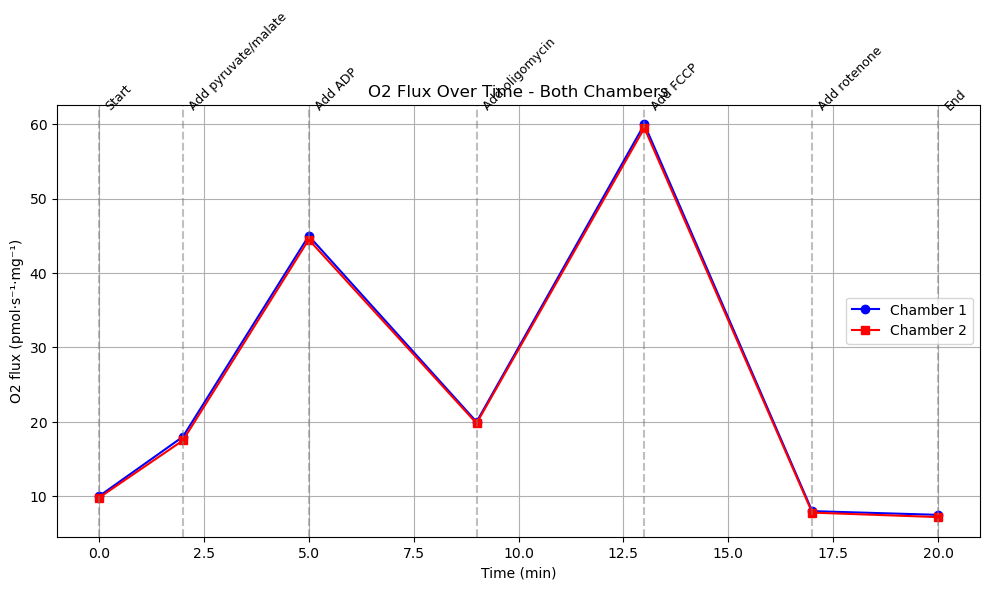

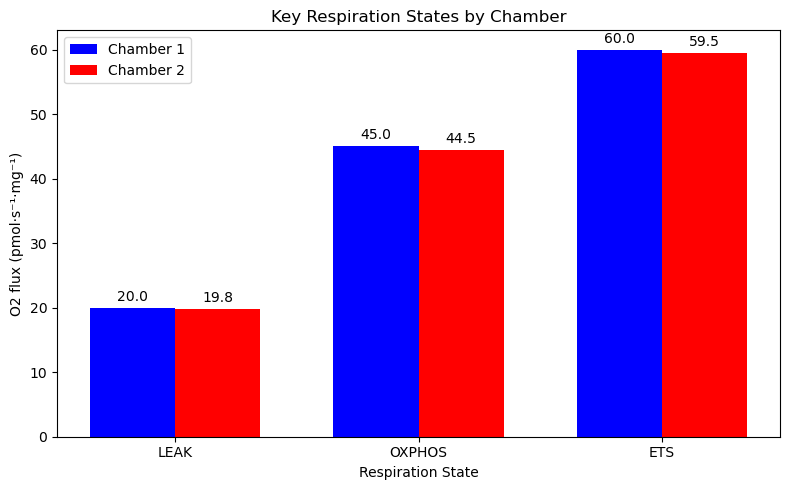

## Compute Ratios


In [11]:
# Compute ratios
efficiency = {
    "OXPHOS/LEAK": [],
    "ETS/OXPHOS": []
}

# Chamber 1 ratios
ch1_LEAK = summary["Chamber 1"][0]
ch1_OXPHOS = summary["Chamber 1"][1]
ch1_ETS = summary["Chamber 1"][2]

efficiency["OXPHOS/LEAK"].append(ch1_OXPHOS / ch1_LEAK)
efficiency["ETS/OXPHOS"].append(ch1_ETS / ch1_OXPHOS)

# Chamber 2 ratios
ch2_LEAK = summary["Chamber 2"][0]
ch2_OXPHOS = summary["Chamber 2"][1]
ch2_ETS = summary["Chamber 2"][2]

efficiency["OXPHOS/LEAK"].append(ch2_OXPHOS / ch2_LEAK)
efficiency["ETS/OXPHOS"].append(ch2_ETS / ch2_OXPHOS)


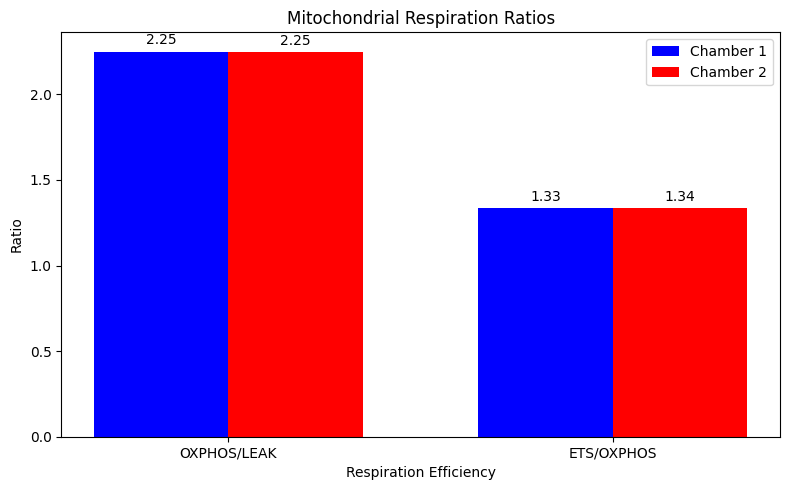

In [12]:
# Plot ratios
ratios_labels = list(efficiency.keys())
ch1_ratios = [efficiency[key][0] for key in ratios_labels]
ch2_ratios = [efficiency[key][1] for key in ratios_labels]

x = np.arange(len(ratios_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
rects1 = ax.bar(x - width/2, ch1_ratios, width, label='Chamber 1', color='blue')
rects2 = ax.bar(x + width/2, ch2_ratios, width, label='Chamber 2', color='red')

# Labels and title
ax.set_ylabel('Ratio')
ax.set_xlabel('Respiration Efficiency')
ax.set_title('Mitochondrial Respiration Ratios')
ax.set_xticks(x)
ax.set_xticklabels(ratios_labels)
ax.legend()

# Add values on top
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()
plt.show()
